In [1]:
# 导入项目所需的主要工具
# Import the main libraries required for the project
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# 如果 CUDA 可用就使用 GPU，否则自动使用 CPU
# Use the GPU when CUDA is available; otherwise use the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", device)

# 显示当前 GPU 名称，方便 Demo 时证明代码确实连接了 GPU
# Display the GPU name as evidence that the notebook is using CUDA
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
Device: cuda
GPU name: Tesla T4


# COMP3710 Lab 1 — Sierpiński Carpet

This notebook implements and analyses a GPU-accelerated Sierpiński Carpet using vectorised PyTorch tensor operations.

## Project Goals

- Generate the Sierpiński Carpet using a pixel-grid and ternary-coordinate algorithm.
- Process all image coordinates in parallel using PyTorch.
- Compare different recursion depths.
- Create multiple colour visualisations.
- Estimate the box-counting dimension.
- Compare the estimated dimension with the theoretical value.
- Compare CPU and GPU execution times.

Recursion depth: 5
Image size: (243, 243)
Occupied pixels: 32768
Expected occupied pixels: 32768
Tensor device: cuda:0


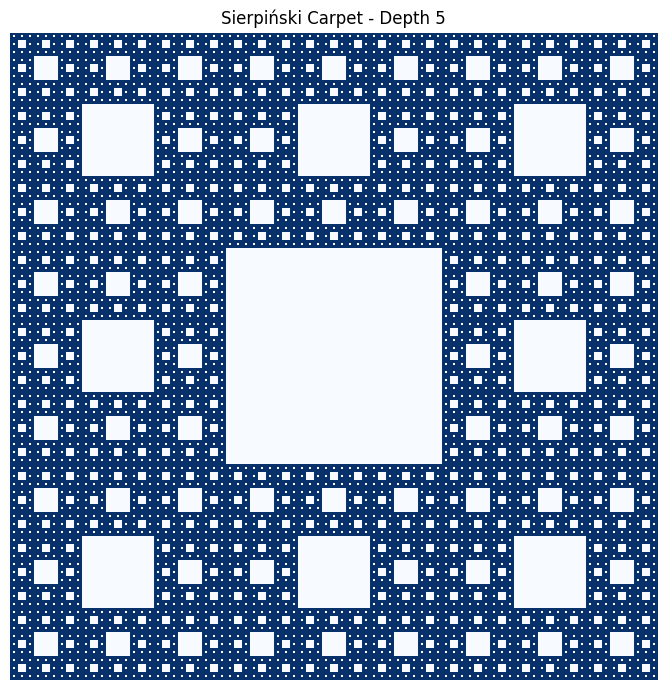

In [2]:
# 生成 Sierpiński Carpet
# Generate a Sierpiński Carpet
def generate_sierpinski_carpet(depth, target_device):
    """
    Generate a Sierpiński Carpet using ternary-coordinate testing.

    depth: recursion depth
    target_device: CPU or GPU device
    """

    # 深度 d 对应的图像边长为 3^d
    # At depth d, the image width and height are 3^d
    size = 3 ** depth

    # 在指定设备上创建所有横纵坐标
    # Create all horizontal and vertical coordinates on the selected device
    coordinates = torch.arange(
        size,
        device=target_device,
        dtype=torch.int64
    )

    y, x = torch.meshgrid(
        coordinates,
        coordinates,
        indexing="ij"
    )

    # True 表示保留该像素，False 表示删除该像素
    # True means the pixel remains; False means it is removed
    carpet = torch.ones(
        (size, size),
        dtype=torch.bool,
        device=target_device
    )

    # 创建坐标副本，用于逐层检查三进制数字
    # Copy the coordinates for checking ternary digits at each level
    check_x = x.clone()
    check_y = y.clone()

    # 这里只循环递归层数，不逐个循环处理像素
    # This loop processes recursion levels, not individual pixels
    for level in range(depth):

        # 如果 x 和 y 当前的三进制位都等于 1，
        # 该像素位于某一层的中央正方形中，需要删除
        # If the current ternary digits of both x and y equal 1,
        # the pixel is inside a centre square and must be removed
        centre_square = (
            (check_x % 3 == 1) &
            (check_y % 3 == 1)
        )

        carpet = carpet & (~centre_square)

        # 删除已经检查过的最低三进制位
        # Remove the ternary digit that has already been checked
        check_x = check_x // 3
        check_y = check_y // 3

    return carpet


# 使用深度 5 生成分形
# Generate the fractal at recursion depth 5
depth = 5
carpet = generate_sierpinski_carpet(depth, device)

# 计算并验证保留像素的数量
# Count and verify the number of remaining pixels
occupied_pixels = int(carpet.sum().item())
expected_pixels = 8 ** depth

print("Recursion depth:", depth)
print("Image size:", tuple(carpet.shape))
print("Occupied pixels:", occupied_pixels)
print("Expected occupied pixels:", expected_pixels)
print("Tensor device:", carpet.device)

# 将结果移回 CPU，以便 Matplotlib 绘图
# Move the result to the CPU for Matplotlib
carpet_image = carpet.cpu().numpy()

plt.figure(figsize=(7, 7))
plt.imshow(
    carpet_image,
    cmap="Blues",
    origin="upper",
    interpolation="nearest"
)
plt.title(f"Sierpiński Carpet - Depth {depth}")
plt.axis("off")
plt.tight_layout()
plt.show()

## Comparison of Different Recursion Depths

This section compares the Sierpiński Carpet at recursion depths 1 to 5.

At each recursion level, every retained square is divided into a 3 × 3 grid. The centre square is removed, while the other eight squares remain. Therefore, the number of occupied pixels at depth d is:

Occupied pixels = 8^d

The comparison demonstrates how the self-similar structure becomes increasingly detailed as the recursion depth increases.

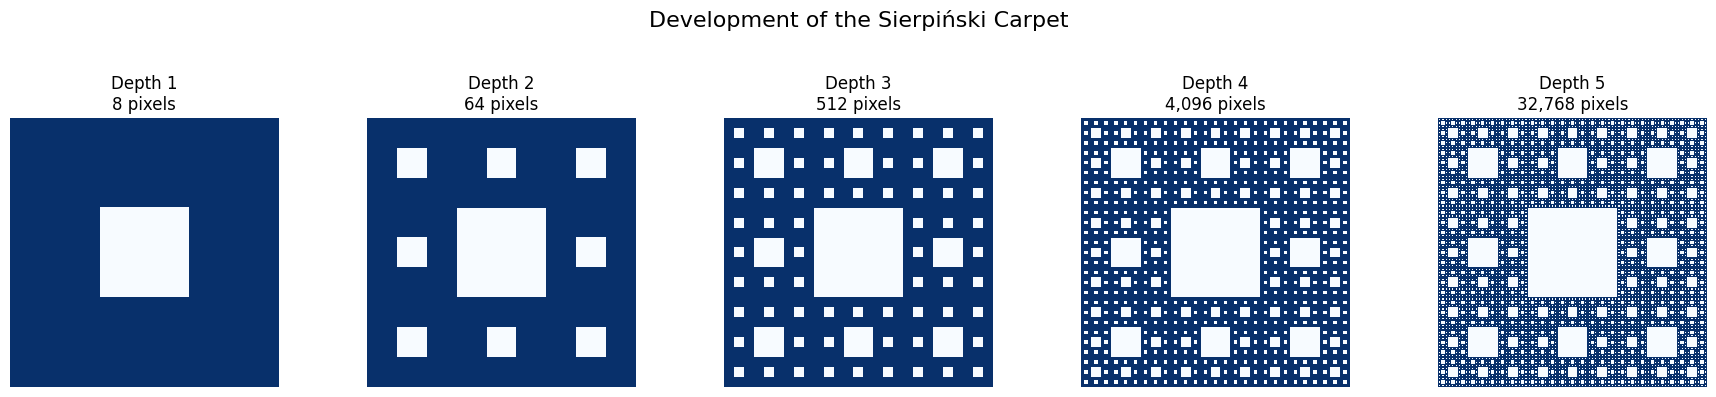

In [4]:
# 比较不同递归深度下 Sierpiński Carpet 的变化
# Compare the Sierpiński Carpet at different recursion depths

comparison_depths = [1, 2, 3, 4, 5]

# 创建一行五张子图
# Create one row containing five subplots
fig, axes = plt.subplots(
    1,
    len(comparison_depths),
    figsize=(18, 4)
)

for axis, current_depth in zip(axes, comparison_depths):

    # 在 GPU 上生成当前深度的 Sierpiński Carpet
    # Generate the carpet at the current depth on the GPU
    current_carpet = generate_sierpinski_carpet(
        current_depth,
        device
    )

    # 计算实际保留的像素数量
    # Count the actual number of remaining pixels
    current_pixels = int(current_carpet.sum().item())

    # 理论上，深度 d 应该保留 8^d 个像素
    # Theoretically, depth d should contain 8^d occupied pixels
    expected_pixels = 8 ** current_depth

    # 检查实际结果是否等于理论结果
    # Check whether the actual result matches the theoretical result
    assert current_pixels == expected_pixels

    # 将张量移回 CPU，以便 Matplotlib 绘图
    # Move the tensor to the CPU for Matplotlib
    current_image = current_carpet.cpu().numpy()

    axis.imshow(
        current_image,
        cmap="Blues",
        origin="upper",
        interpolation="nearest"
    )

    # 标题显示递归深度和保留像素数量
    # Display the recursion depth and occupied pixel count
    axis.set_title(
        f"Depth {current_depth}\n"
        f"{current_pixels:,} pixels"
    )

    axis.axis("off")

# 添加整张比较图的标题，并预留顶部空间
# Add the main title and reserve enough space at the top
fig.suptitle(
    "Development of the Sierpiński Carpet",
    fontsize=16,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.86]
)

plt.show()

## Coordinate-Based Colour Visualisations

The binary image only shows whether each pixel is retained or removed. In this section, colour is used to display additional spatial information.

The first visualisation assigns colour according to the horizontal x-coordinate. The second assigns colour according to the vertical y-coordinate.

The fractal structure remains unchanged, but the colour gradients make the spatial arrangement of the retained pixels easier to interpret.

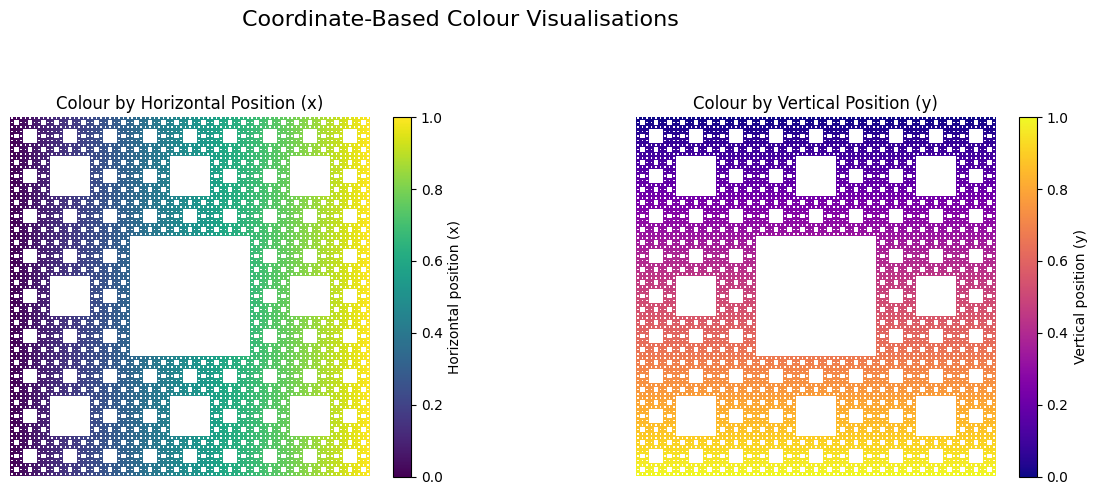

Colour visualisation depth: 5
Image size: (243, 243)
Occupied pixels: 32768
Tensor device: cuda:0


In [5]:
# 使用坐标信息创建两种颜色可视化
# Create two colour visualisations using coordinate information

colour_depth = 5

# 在 GPU 上生成 Sierpiński Carpet
# Generate the Sierpiński Carpet on the GPU
colour_carpet = generate_sierpinski_carpet(
    colour_depth,
    device
)

image_size = colour_carpet.shape[0]

# 创建从 0 到 1 的标准化坐标
# Create normalised coordinates ranging from 0 to 1
normalised_coordinates = torch.linspace(
    0.0,
    1.0,
    image_size,
    device=device
)

colour_y, colour_x = torch.meshgrid(
    normalised_coordinates,
    normalised_coordinates,
    indexing="ij"
)

# 为删除的像素设置 NaN，使中央空白区域不显示颜色
# Use NaN for removed pixels so that empty regions remain blank
empty_pixels = torch.full_like(
    colour_x,
    float("nan")
)

# 第一种颜色由横坐标 x 决定
# The first colour value is determined by horizontal position x
horizontal_colours = torch.where(
    colour_carpet,
    colour_x,
    empty_pixels
)

# 第二种颜色由纵坐标 y 决定
# The second colour value is determined by vertical position y
vertical_colours = torch.where(
    colour_carpet,
    colour_y,
    empty_pixels
)

# 将结果移回 CPU，供 Matplotlib 绘图
# Move the results to the CPU for Matplotlib
horizontal_image = horizontal_colours.cpu().numpy()
vertical_image = vertical_colours.cpu().numpy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# 横坐标颜色图
# Horizontal-coordinate colour map
horizontal_plot = axes[0].imshow(
    horizontal_image,
    cmap="viridis",
    origin="upper",
    interpolation="nearest"
)

axes[0].set_title("Colour by Horizontal Position (x)")
axes[0].axis("off")

horizontal_colourbar = fig.colorbar(
    horizontal_plot,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

horizontal_colourbar.set_label(
    "Horizontal position (x)"
)

# 纵坐标颜色图
# Vertical-coordinate colour map
vertical_plot = axes[1].imshow(
    vertical_image,
    cmap="plasma",
    origin="upper",
    interpolation="nearest"
)

axes[1].set_title("Colour by Vertical Position (y)")
axes[1].axis("off")

vertical_colourbar = fig.colorbar(
    vertical_plot,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

vertical_colourbar.set_label(
    "Vertical position (y)"
)

# 添加整张图的标题
# Add a title for the complete visualisation
fig.suptitle(
    "Coordinate-Based Colour Visualisations",
    fontsize=16,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.91]
)

plt.show()

print("Colour visualisation depth:", colour_depth)
print("Image size:", tuple(colour_carpet.shape))
print("Occupied pixels:", int(colour_carpet.sum().item()))
print("Tensor device:", colour_carpet.device)

## Box-Counting Dimension Analysis

The box-counting dimension measures how the number of occupied boxes changes as the box size becomes smaller.

For a box size ε, let N(ε) be the number of boxes containing at least one retained pixel. The dimension is estimated from the slope of:

log(N(ε)) against log(1/ε)

For the Sierpiński Carpet, each square is replaced by eight smaller squares, each scaled by a factor of 1/3. Therefore, its theoretical dimension is:

D = log(8) / log(3) ≈ 1.8928

The estimated dimension below is compared with this theoretical value.

Analysis depth: 6
Image size: (729, 729)
Analysis tensor device: cuda:0

Box size | Occupied boxes
       1 |         262144
       3 |          32768
       9 |           4096
      27 |            512
      81 |             64
     243 |              8
     729 |              1

Estimated dimension: 1.8928
Theoretical dimension: 1.8928
Absolute error: 0.0000


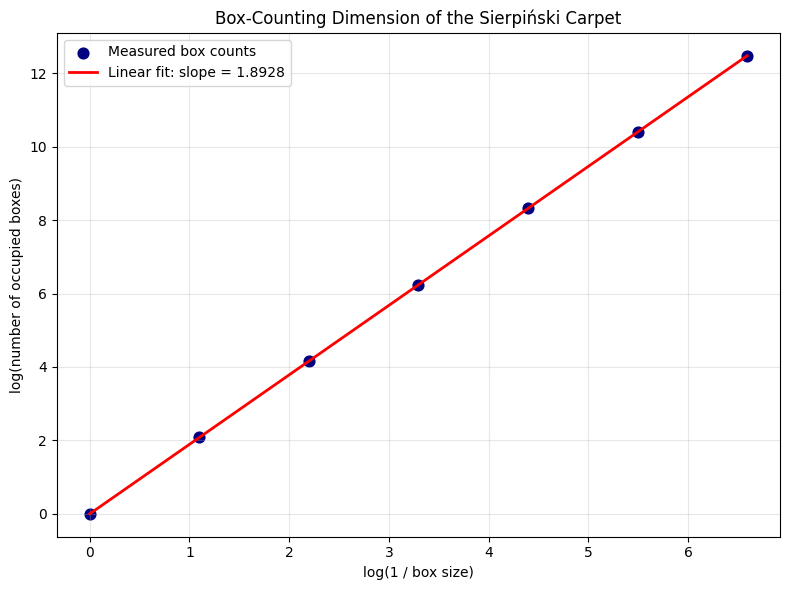

In [6]:
# 使用箱计数法估计 Sierpiński Carpet 的分形维度
# Estimate the fractal dimension using the box-counting method

dimension_depth = 6

# 在 GPU 上生成用于维度分析的分形
# Generate the fractal for dimension analysis on the GPU
dimension_carpet = generate_sierpinski_carpet(
    dimension_depth,
    device
)

image_size = dimension_carpet.shape[0]

# 选择能够整除图像尺寸的箱子边长
# Select box sizes that divide the image size exactly
box_sizes = [
    3 ** level
    for level in range(dimension_depth + 1)
]

occupied_box_counts = []
inverse_box_scales = []

for box_size in box_sizes:

    # 每条边上包含多少个箱子
    # Number of boxes along each side
    boxes_per_side = image_size // box_size

    # 将图像重新排列成多个小箱子
    # Reshape the image into separate square boxes
    boxed_image = dimension_carpet.reshape(
        boxes_per_side,
        box_size,
        boxes_per_side,
        box_size
    )

    # 如果箱子中至少有一个保留像素，就认为该箱子被占用
    # A box is occupied if it contains at least one retained pixel
    occupied_box_grid = (
        boxed_image
        .any(dim=3)
        .any(dim=1)
    )

    number_of_occupied_boxes = int(
        occupied_box_grid.sum().item()
    )

    # ε = 箱子边长 / 图像边长，所以 1/ε = 图像边长 / 箱子边长
    # epsilon = box size / image size
    inverse_scale = image_size / box_size

    occupied_box_counts.append(
        number_of_occupied_boxes
    )

    inverse_box_scales.append(
        inverse_scale
    )

# 转换为对数，进行直线拟合
# Convert the measurements to logarithms for linear fitting
log_inverse_scales = np.log(
    np.array(inverse_box_scales, dtype=float)
)

log_box_counts = np.log(
    np.array(occupied_box_counts, dtype=float)
)

# 拟合直线的斜率就是估计的箱计数维度
# The slope of the fitted line is the estimated dimension
estimated_dimension, intercept = np.polyfit(
    log_inverse_scales,
    log_box_counts,
    1
)

fitted_values = (
    estimated_dimension * log_inverse_scales
    + intercept
)

# 计算理论分形维度
# Calculate the theoretical fractal dimension
theoretical_dimension = math.log(8) / math.log(3)

absolute_error = abs(
    estimated_dimension - theoretical_dimension
)

print("Analysis depth:", dimension_depth)
print("Image size:", tuple(dimension_carpet.shape))
print("Analysis tensor device:", dimension_carpet.device)
print()
print("Box size | Occupied boxes")

for box_size, box_count in zip(
    box_sizes,
    occupied_box_counts
):
    print(f"{box_size:8d} | {box_count:14d}")

print()
print(
    f"Estimated dimension: {estimated_dimension:.4f}"
)
print(
    f"Theoretical dimension: {theoretical_dimension:.4f}"
)
print(
    f"Absolute error: {absolute_error:.4f}"
)

# 绘制对数数据点和拟合直线
# Plot the logarithmic measurements and fitted line
plt.figure(figsize=(8, 6))

plt.scatter(
    log_inverse_scales,
    log_box_counts,
    color="navy",
    s=60,
    label="Measured box counts"
)

plt.plot(
    log_inverse_scales,
    fitted_values,
    color="red",
    linewidth=2,
    label=(
        f"Linear fit: slope = "
        f"{estimated_dimension:.4f}"
    )
)

plt.xlabel("log(1 / box size)")
plt.ylabel("log(number of occupied boxes)")
plt.title(
    "Box-Counting Dimension of the Sierpiński Carpet"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## CPU and GPU Performance Comparison

This section compares the execution time of the same vectorised Sierpiński Carpet algorithm on the CPU and GPU.

For a fair comparison, both devices use the same PyTorch function and the same recursion depths. Each test is repeated several times, and the mean execution time is reported.

CUDA operations are asynchronous, so `torch.cuda.synchronize()` is used before and after GPU timing to ensure that the recorded time includes the completed GPU computation.

For small workloads, GPU overhead may make the GPU slower than the CPU. As the image size increases, the GPU is expected to become more effective because many pixel coordinates can be processed in parallel.

GPU used: Tesla T4
Number of repetitions: 5

Depth | Grid pixels | Retained pixels | CPU time (ms) | GPU time (ms) | Speedup
    3 |         729 |             512 |         4.855 |         0.512 |    9.48x
    4 |        6561 |            4096 |         1.434 |         0.563 |    2.55x
    5 |       59049 |           32768 |        15.673 |         0.630 |   24.90x
    6 |      531441 |          262144 |       184.757 |         1.616 |  114.31x
    7 |     4782969 |         2097152 |      2060.362 |        13.429 |  153.43x


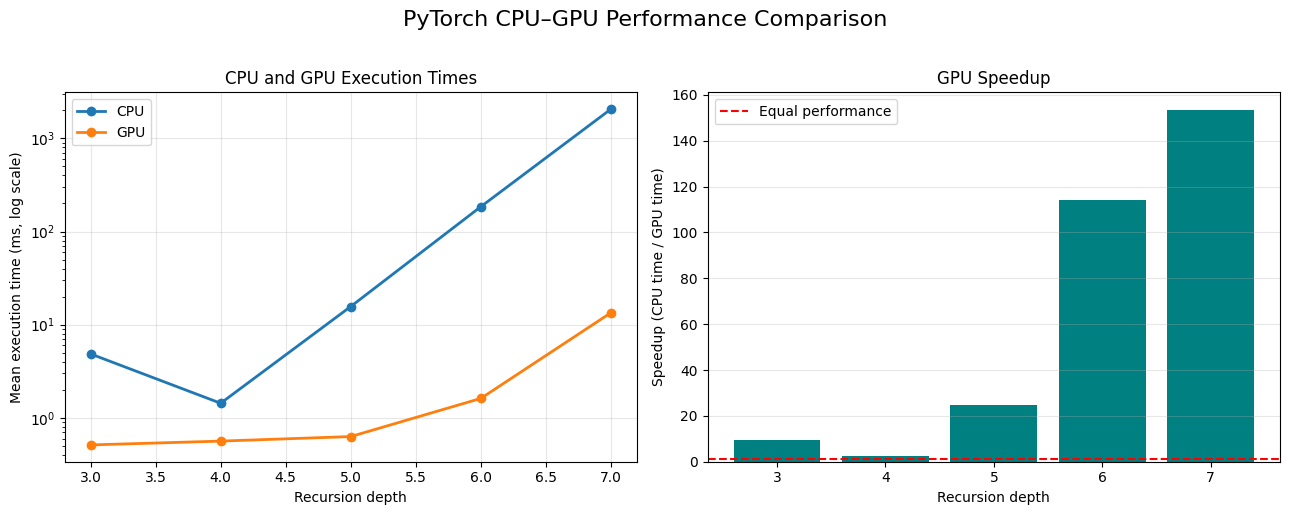

In [7]:
# 比较同一个算法在 CPU 和 GPU 上的执行时间
# Compare the execution time of the same algorithm on the CPU and GPU

# 确保当前运行环境已经连接 CUDA GPU
# Ensure that the current runtime has a CUDA GPU
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is not available. Please select a T4 GPU runtime."
    )

cpu_device = torch.device("cpu")
gpu_device = torch.device("cuda")

# 每个测试重复多次，以减少单次测量波动
# Repeat every test several times to reduce timing variation
number_of_repetitions = 5

# 测试不同递归深度
# Test several recursion depths
benchmark_depths = [3, 4, 5, 6, 7]


def measure_generation_time(
    recursion_depth,
    target_device,
    repetitions
):
    """
    Measure the mean execution time of the carpet generator.
    """

    execution_times = []

    for repetition in range(repetitions):

        # CUDA 操作是异步的，因此计时前先等待之前的操作完成
        # CUDA operations are asynchronous, so synchronise before timing
        if target_device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        generated_carpet = generate_sierpinski_carpet(
            recursion_depth,
            target_device
        )

        # 等待 GPU 完成全部计算后再停止计时
        # Wait for all GPU calculations to finish before stopping the timer
        if target_device.type == "cuda":
            torch.cuda.synchronize()

        end_time = time.perf_counter()

        elapsed_milliseconds = (
            end_time - start_time
        ) * 1000

        execution_times.append(
            elapsed_milliseconds
        )

        # 删除本次结果，避免不同测试之间保存不需要的张量
        # Delete the result so unnecessary tensors are not retained
        del generated_carpet

    mean_time = float(
        np.mean(execution_times)
    )

    standard_deviation = float(
        np.std(execution_times)
    )

    return mean_time, standard_deviation


# 先运行一次较小的 GPU 任务，让 CUDA 完成初始化
# Run a small GPU warm-up so CUDA completes its initial setup
warm_up_carpet = generate_sierpinski_carpet(
    3,
    gpu_device
)

torch.cuda.synchronize()
del warm_up_carpet


cpu_times = []
gpu_times = []
cpu_standard_deviations = []
gpu_standard_deviations = []
speedups = []

print(
    "GPU used:",
    torch.cuda.get_device_name(0)
)
print(
    "Number of repetitions:",
    number_of_repetitions
)
print()

print(
    "Depth | Grid pixels | Retained pixels | "
    "CPU time (ms) | GPU time (ms) | Speedup"
)

for benchmark_depth in benchmark_depths:

    # 计算整个坐标网格和最终保留像素的数量
    # Calculate the full grid size and retained-pixel count
    side_length = 3 ** benchmark_depth
    number_of_grid_pixels = side_length ** 2
    number_of_retained_pixels = 8 ** benchmark_depth

    cpu_mean, cpu_std = measure_generation_time(
        benchmark_depth,
        cpu_device,
        number_of_repetitions
    )

    gpu_mean, gpu_std = measure_generation_time(
        benchmark_depth,
        gpu_device,
        number_of_repetitions
    )

    speedup = cpu_mean / gpu_mean

    cpu_times.append(cpu_mean)
    gpu_times.append(gpu_mean)

    cpu_standard_deviations.append(cpu_std)
    gpu_standard_deviations.append(gpu_std)

    speedups.append(speedup)

    print(
        f"{benchmark_depth:5d} | "
        f"{number_of_grid_pixels:11d} | "
        f"{number_of_retained_pixels:15d} | "
        f"{cpu_mean:13.3f} | "
        f"{gpu_mean:13.3f} | "
        f"{speedup:7.2f}x"
    )


# 绘制执行时间和 GPU 加速比
# Plot execution times and GPU speedup
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# 左图：CPU 和 GPU 执行时间
# Left: CPU and GPU execution times
axes[0].plot(
    benchmark_depths,
    cpu_times,
    marker="o",
    linewidth=2,
    label="CPU"
)

axes[0].plot(
    benchmark_depths,
    gpu_times,
    marker="o",
    linewidth=2,
    label="GPU"
)

axes[0].set_yscale("log")
axes[0].set_xlabel("Recursion depth")
axes[0].set_ylabel("Mean execution time (ms, log scale)")
axes[0].set_title("CPU and GPU Execution Times")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 右图：CPU 时间除以 GPU 时间得到的加速比
# Right: speedup calculated as CPU time divided by GPU time
axes[1].bar(
    benchmark_depths,
    speedups,
    color="teal"
)

# 加速比等于 1 表示 CPU 和 GPU 速度相同
# A speedup of 1 means equal CPU and GPU performance
axes[1].axhline(
    1.0,
    color="red",
    linestyle="--",
    label="Equal performance"
)

axes[1].set_xlabel("Recursion depth")
axes[1].set_ylabel("Speedup (CPU time / GPU time)")
axes[1].set_title("GPU Speedup")
axes[1].grid(
    axis="y",
    alpha=0.3
)
axes[1].legend()

fig.suptitle(
    "PyTorch CPU–GPU Performance Comparison",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()